<a href="https://colab.research.google.com/github/yes-im-harsh/Membership_Inference_SVHN/blob/main/Membership_SVHN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils import to_categorical
from torchvision.datasets import SVHN
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

In [2]:
print("Downloading SVHN...")
train_raw = SVHN(root="./data", split="train", download=True)
test_raw  = SVHN(root="./data", split="test",  download=True)

def to_numpy(dataset):
    images, labels = [], []
    for img, label in dataset:
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(label)
    return np.stack(images), np.array(labels, dtype=np.int64)

train_data, train_labels = to_numpy(train_raw)
test_data, test_labels   = to_numpy(test_raw)
NUM_CLASSES = int(max(train_labels.max(), test_labels.max())) + 1

print("Train:", train_data.shape, "| Test:", test_data.shape, "| Classes:", NUM_CLASSES)

100%|██████████| 182M/182M [02:41<00:00, 1.13MB/s]
100%|██████████| 64.3M/64.3M [01:12<00:00, 889kB/s] 


Train: (73257, 32, 32, 3) | Test: (26032, 32, 32, 3) | Classes: 10


In [4]:
def make_simple_model():
    shape = (32, 32, 3)
    i = Input(shape=shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(i)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(NUM_CLASSES)(x)  # logits
    return Model(i, x)

model = make_simple_model()
optimizer = tf.keras.optimizers.Adam()
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
history = model.fit(train_data, train_labels,
                     validation_data=(test_data, test_labels),
                     batch_size=128,
                     epochs=30)

Epoch 1/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 91s 155ms/step - accuracy: 0.6157 - loss: 1.1871 - val_accuracy: 0.8100 - val_loss: 0.6947
Epoch 2/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 138s 148ms/step - accuracy: 0.8376 - loss: 0.5757 - val_accuracy: 0.8507 - val_loss: 0.5544
Epoch 3/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 145s 154ms/step - accuracy: 0.8661 - loss: 0.4771 - val_accuracy: 0.8639 - val_loss: 0.5021
Epoch 4/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 85s 148ms/step - accuracy: 0.8821 - loss: 0.4188 - val_accuracy: 0.8723 - val_loss: 0.4613
Epoch 5/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 143s 150ms/step - accuracy: 0.8924 - loss: 0.3749 - val_accuracy: 0.8825 - val_loss: 0.4246
Epoch 6/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 85s 149ms/step - accuracy: 0.9012 - loss: 0.3424 - val_accuracy: 0.8877 - val_loss: 0.4001
Epoch 7/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 142s 148ms/step - accuracy: 0.9081 - loss: 0.3177 - val_accuracy: 0.8879 - val_loss: 0.3953
Epoch 8/30
573/573 ━━━━━━━━━━━━━━━━━━━━ 88s 154ms/step - accuracy: 0.9138 - los

In [7]:
logits_train = model.predict(train_data, batch_size=256, verbose=0)
logits_test  = model.predict(test_data,  batch_size=256, verbose=0)
prob_train = tf.nn.softmax(logits_train, axis=-1).numpy()
prob_test  = tf.nn.softmax(logits_test,  axis=-1).numpy()

y_train_onehot = to_categorical(train_labels, num_classes=NUM_CLASSES)
y_test_onehot  = to_categorical(test_labels,  num_classes=NUM_CLASSES)
cce, constant = tf.keras.backend.categorical_crossentropy, tf.keras.backend.constant
loss_train = cce(constant(y_train_onehot), constant(prob_train), from_logits=False).numpy()
loss_test  = cce(constant(y_test_onehot),  constant(prob_test),  from_logits=False).numpy()

correct_train = (prob_train.argmax(axis=1) == train_labels)
correct_test  = (prob_test.argmax(axis=1) == test_labels)

all_loss = np.concatenate([loss_train, loss_test])
all_conf = np.concatenate([prob_train.max(axis=1), prob_test.max(axis=1)])
all_correct = np.concatenate([correct_train, correct_test]).astype(int)
all_class = np.concatenate([train_labels, test_labels])
y_membership = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

results = {}

score = -all_loss
auc = roc_auc_score(y_membership, score)
fpr, tpr, _ = roc_curve(y_membership, score)
advantage = np.max(tpr - fpr)
results["threshold"] = {"auc": auc, "advantage": advantage, "roc": (fpr, tpr)}
print(f"Threshold attack (entire dataset):   AUC = {auc:.3f}   advantage = {advantage:.3f}")

X = np.stack([all_loss, all_conf], axis=1)
X_tr, X_ev, y_tr, y_ev = train_test_split(X, y_membership, test_size=0.5, stratify=y_membership, random_state=0)
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
scores_ev = clf.predict_proba(X_ev)[:, 1]
auc_lr = roc_auc_score(y_ev, scores_ev)
fpr_lr, tpr_lr, _ = roc_curve(y_ev, scores_ev)
advantage_lr = np.max(tpr_lr - fpr_lr)
results["logistic_regression"] = {"auc": auc_lr, "advantage": advantage_lr, "roc": (fpr_lr, tpr_lr)}
print(f"Logistic regression attack (entire dataset):   AUC = {auc_lr:.3f}   advantage = {advantage_lr:.3f}")

print("\nBy classification correctness:")
for label, mask in [("correctly classified", all_correct == 1), ("misclassified", all_correct == 0)]:
    if mask.sum() > 10 and len(set(y_membership[mask])) == 2:
        fpr_s, tpr_s, _ = roc_curve(y_membership[mask], score[mask])
        auc_s = roc_auc_score(y_membership[mask], score[mask])
        adv_s = np.max(tpr_s - fpr_s)
        results[f"correctness:{label}"] = {"auc": auc_s, "advantage": adv_s, "roc": (fpr_s, tpr_s)}
        print(f"  {label}: AUC = {auc_s:.3f}   advantage = {adv_s:.3f}  (n={mask.sum()})")

print("\nBy class:")
for c in range(NUM_CLASSES):
    mask = all_class == c
    if mask.sum() > 10 and len(set(y_membership[mask])) == 2:
        fpr_s, tpr_s, _ = roc_curve(y_membership[mask], score[mask])
        auc_s = roc_auc_score(y_membership[mask], score[mask])
        adv_s = np.max(tpr_s - fpr_s)
        results[f"class:{c}"] = {"auc": auc_s, "advantage": adv_s, "roc": (fpr_s, tpr_s)}
        print(f"  class {c}: AUC = {auc_s:.3f}   advantage = {adv_s:.3f}  (n={mask.sum()})")

Threshold attack (entire dataset):   AUC = 0.566   advantage = 0.085
Logistic regression attack (entire dataset):   AUC = 0.567   advantage = 0.092

By classification correctness:
  correctly classified: AUC = 0.533   advantage = 0.063  (n=94607)
  misclassified: AUC = 0.717   advantage = 0.347  (n=4682)

By class:
  class 0: AUC = 0.574   advantage = 0.102  (n=6692)
  class 1: AUC = 0.568   advantage = 0.104  (n=18960)
  class 2: AUC = 0.553   advantage = 0.077  (n=14734)
  class 3: AUC = 0.582   advantage = 0.124  (n=11379)
  class 4: AUC = 0.568   advantage = 0.098  (n=9981)
  class 5: AUC = 0.570   advantage = 0.098  (n=9266)
  class 6: AUC = 0.558   advantage = 0.086  (n=7704)
  class 7: AUC = 0.540   advantage = 0.070  (n=7614)
  class 8: AUC = 0.613   advantage = 0.151  (n=6705)
  class 9: AUC = 0.576   advantage = 0.118  (n=6254)


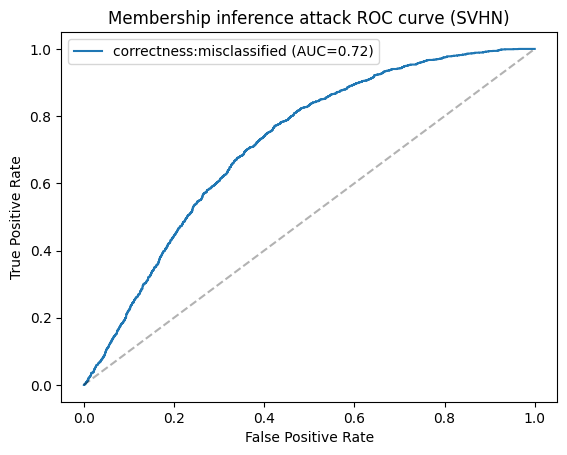

In [8]:
best_attack = max(results, key=lambda k: results[k]["auc"])
fpr, tpr = results[best_attack]["roc"]
plt.plot(fpr, tpr, label=f"{best_attack} (AUC={results[best_attack]['auc']:.2f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership inference attack ROC curve (SVHN)")
plt.legend()
plt.show()